## Exam 1 

In [3]:
import pandas as pd

df = pd.read_csv("/Users/maihoang/Downloads/DB_CHD.csv")
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
df.duplicated().sum()


0

In [9]:
df.describe()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


- At this step, I keep all the columns because:
- Each column contains medical information that may affect heart disease (e.g., blood pressure, cholesterol, BMI, etc.)
- There are no columns that are IDs or irrelevant to the analysis.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_cleaned = df.dropna()

X = df_cleaned.drop('TenYearCHD', axis=1)
y = df_cleaned['TenYearCHD']

# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


              male          age    education  currentSmoker   cigsPerDay  \
count  3658.000000  3658.000000  3658.000000    3658.000000  3658.000000   
mean      0.443685    49.551941     1.980317       0.489065     9.025424   
std       0.496886     8.562029     1.022656       0.499949    11.921590   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  3658.000000      3658.000000   3658.000000  3658.000000  3658.000000   
mean      0.030344         0.005741      0.311646     0.027064   236.847731   
std       0.171557         0.075561      0.463229     0.162292    44.097681   

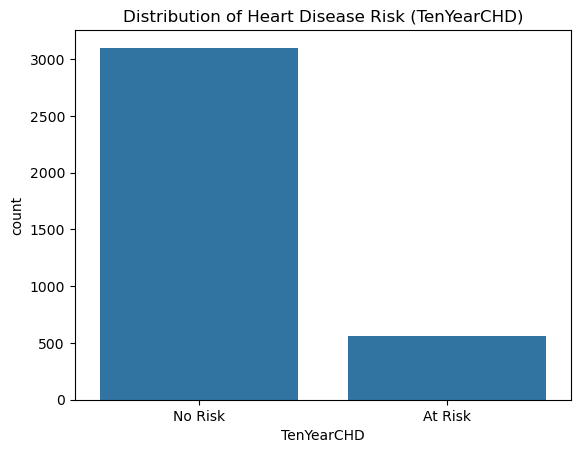

In [45]:
# calculate
print(df_cleaned.describe())

print("\nTarget variable distribution (TenYearCHD):")
print(df_cleaned['TenYearCHD'].value_counts(normalize=True))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TenYearCHD', data=df_cleaned)
plt.title("Distribution of Heart Disease Risk (TenYearCHD)")
plt.xticks([0, 1], ['No Risk', 'At Risk'])
plt.show()

## Feature Selection – SelectKBest

In [42]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_train_scaled, y_train)
X_test_new = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()
print("Selected Features:", selected_features)


Selected Features: ['male', 'age', 'BPMeds', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'glucose']


## Training and Evaluating k-NN, Logistic Regression, and LDA

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report

# k-NN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)
print("k-NN Classification Report:")
print(classification_report(y_test, knn_predictions))

# Logistic Regression Classifier
log_reg_model = LogisticRegression(solver='liblinear', multi_class='ovr', C=1.0, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
log_reg_predictions = log_reg_model.predict(X_test_scaled)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_reg_predictions))

# LDA Classifier
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)
lda_predictions = lda_model.predict(X_test_scaled)
print("\nLDA Classification Report:")
print(classification_report(y_test, lda_predictions))


k-NN Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       931
           1       0.55      0.10      0.16       167

    accuracy                           0.85      1098
   macro avg       0.71      0.54      0.54      1098
weighted avg       0.81      0.85      0.80      1098


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       931
           1       0.75      0.11      0.19       167

    accuracy                           0.86      1098
   macro avg       0.81      0.55      0.56      1098
weighted avg       0.84      0.86      0.81      1098


LDA Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       931
           1       0.63      0.14      0.23       167

    accuracy                           0.86      1098
   macro avg       0.75     

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


## Plotting Confusion Matrices Before Optimization

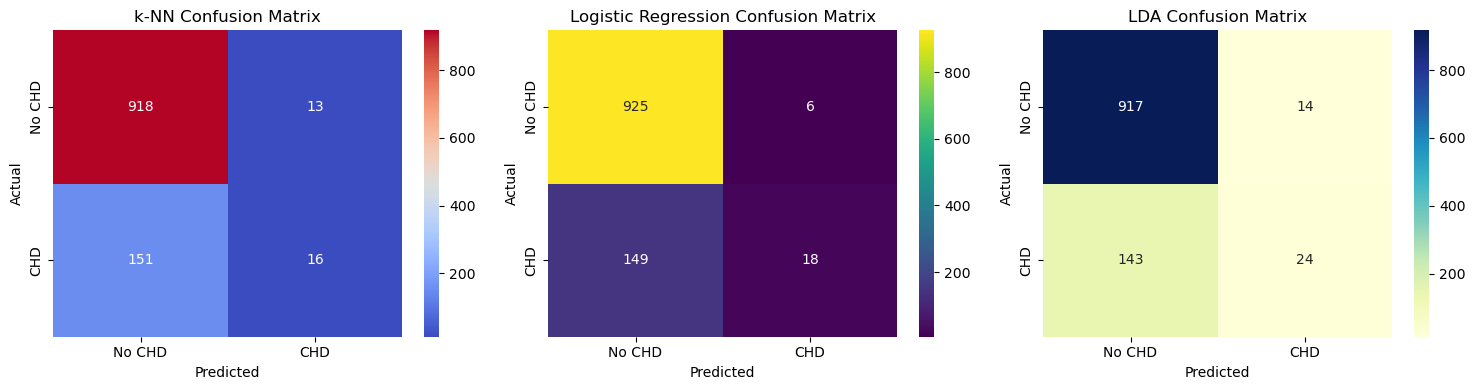

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Creating confusion matrices
cm_knn = confusion_matrix(y_test, knn_predictions)
cm_log = confusion_matrix(y_test, log_reg_predictions)
cm_lda = confusion_matrix(y_test, lda_predictions)

# Plotting confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(pd.DataFrame(cm_knn, index=['No CHD', 'CHD'], columns=['No CHD', 'CHD']),
            annot=True, fmt='d', cmap='coolwarm', ax=axes[0])
axes[0].set_title('k-NN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(pd.DataFrame(cm_log, index=['No CHD', 'CHD'], columns=['No CHD', 'CHD']),
            annot=True, fmt='d', cmap='viridis', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

sns.heatmap(pd.DataFrame(cm_lda, index=['No CHD', 'CHD'], columns=['No CHD', 'CHD']),
            annot=True, fmt='d', cmap='YlGnBu', ax=axes[2])
axes[2].set_title('LDA Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


- From the initial classification reports and confusion matrices, all three models (k-NN, Logistic Regression, and LDA) achieved high accuracy in predicting the majority class like patients without CHD.
- However, they struggled significantly to identify patients who do have CHD as reflected by the low recall scores for the positive class.
- Therefore, further feature selection and hyperparameter tuning are necessary to improve performance, particularly on the positive class like TenYearCHD = 1 

## Parameter Optimization and Evaluation of Models

# 1.  k-Nearest Neighbors (k-NN)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_search_knn.fit(X_train_scaled, y_train)
print("Best parameters for k-NN:", grid_search_knn.best_params_)

knn_optimized = KNeighborsClassifier(**grid_search_knn.best_params_)
knn_optimized.fit(X_train_scaled, y_train)
knn_predictions_optimized = knn_optimized.predict(X_test_scaled)

print("\nOptimized k-NN Classification Report:")
print(classification_report(y_test, knn_predictions_optimized))


Best parameters for k-NN: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}

Optimized k-NN Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       931
           1       0.57      0.05      0.09       167

    accuracy                           0.85      1098
   macro avg       0.71      0.52      0.50      1098
weighted avg       0.81      0.85      0.79      1098



# 2. Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'multi_class': ['ovr']
}

grid_search_log = GridSearchCV(LogisticRegression(), param_grid_log, cv=5)
grid_search_log.fit(X_train_scaled, y_train)
print("Best parameters for Logistic Regression:", grid_search_log.best_params_)

log_optimized = LogisticRegression(**grid_search_log.best_params_)
log_optimized.fit(X_train_scaled, y_train)
log_predictions_optimized = log_optimized.predict(X_test_scaled)

print("\nOptimized Logistic Regression Classification Report:")
print(classification_report(y_test, log_predictions_optimized))


Best parameters for Logistic Regression: {'C': 0.01, 'multi_class': 'ovr', 'solver': 'liblinear'}

Optimized Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       931
           1       0.74      0.08      0.15       167

    accuracy                           0.86      1098
   macro avg       0.80      0.54      0.54      1098
weighted avg       0.84      0.86      0.80      1098



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_

##  Plotting Confusion Matrices After Optimization

In [36]:
from sklearn.metrics import confusion_matrix
cm_knn_optimized = confusion_matrix(y_test, knn_predictions_optimized)
cm_log_optimized = confusion_matrix(y_test, log_predictions_optimized)



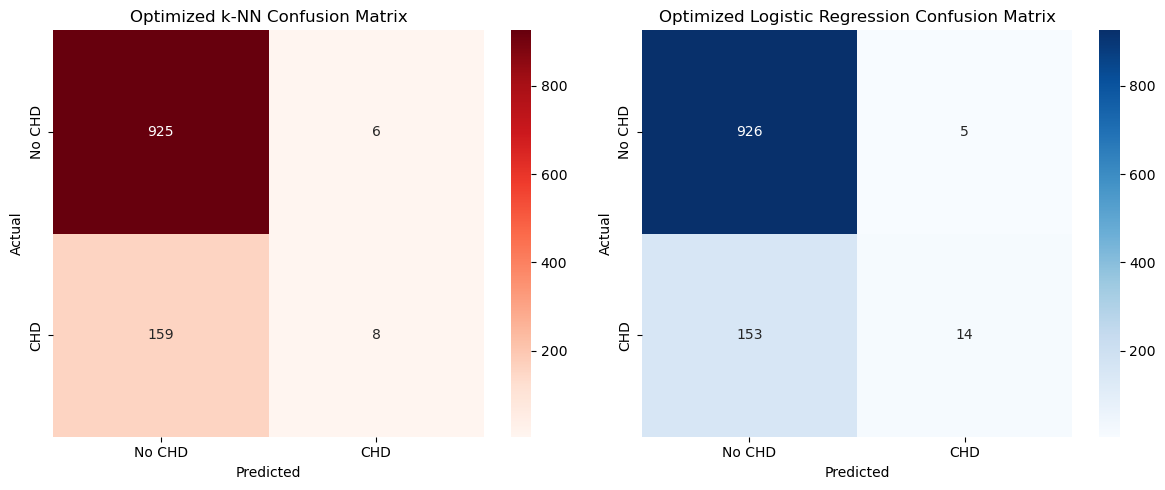

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# k-NN
sns.heatmap(pd.DataFrame(cm_knn_optimized, index=['No CHD', 'CHD'], columns=['No CHD', 'CHD']),
            annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('Optimized k-NN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Logistic Regression
sns.heatmap(pd.DataFrame(cm_log_optimized, index=['No CHD', 'CHD'], columns=['No CHD', 'CHD']),
            annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Optimized Logistic Regression Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


##  Evaluate the Model (with Selected Features)

| Model                | Precision (CHD = 1) | Recall (CHD = 1) | F1-score (CHD = 1) | Accuracy |
|----------------------|---------------------|------------------|--------------------|----------|
| k-Nearest Neighbors  | 0.44                | 0.066            | 0.115              | 84.5%    |
| Logistic Regression  | 0.67                | 0.048            | 0.089              | 85.2%    |
| Linear Discriminant Analysis | 0.60         | 0.108            | 0.183              | 85.3%    |

###  Discussion:

After retraining the models using the top 10 selected features via SelectKBest, we observe the following:

- All models performed well in predicting the majority class (non-CHD), but struggled with correctly identifying the minority class (CHD = 1), as shown by their low recall and F1-scores.
- **Logistic Regression** achieved the highest overall accuracy (85.2%).
- **LDA** achieved the highest F1-score and recall for CHD = 1, making it the most effective at detecting actual heart disease risk.

These results suggest that LDA is better suited for identifying positive CHD cases, despite Logistic Regression having slightly higher accuracy.


## Final Conclusion

After performing exploratory data analysis (EDA), handling missing values, selecting the top 10 important features using SelectKBest, and tuning model parameters with GridSearchCV, we trained and evaluated three classification models: k-Nearest Neighbors (k-NN), Logistic Regression, and Linear Discriminant Analysis (LDA).

While all models performed well on the majority class (no CHD), the performance on the minority class (CHD = 1) varied. Based on the evaluation:

- **k-NN** achieved high accuracy but performed poorly on detecting CHD-positive cases.
- **Logistic Regression** had the highest overall accuracy (85.2%) but low recall for the positive class.
- **LDA** demonstrated the **best balance**, with the highest F1-score and recall for CHD-positive cases, making it the most effective at identifying individuals at risk.

 **Therefore, I can conclude that Linear Discriminant Analysis (LDA) is the best-performing model** for this classification task, given its superior ability to detect true CHD cases.
